# Reducing the upper limit on fitness (beneficial=1e-6)

**Parameter.** There are two versions of this notebook. The only cell in which they differ is the following, where the parameter indicating the fraction of mutations that are beneficial is assigned a value of either `'1e-3'` or `'1e-6'`.

In [1]:
fraction_of_mutations_that_are_beneficial = '1e-6'

!TZ=America/Los_Angeles date

Sat Nov  3 20:02:24 PDT 2018


## Introduction



### Overview of the experiment

[<span style='color:red;'>More here</span>]

**Note on viewing results.** We recommend opening different versions of this notebook in different windows, and placing the windows side-by-side. It may be helpful, when comparing graphical outputs, to reduce the scale of display in the windows.

In [2]:
%matplotlib notebook
%run ../../Code/bs.py
%run -i ../../Code/multiprecision_gamma.py
%run -i ../../Code/gamma.py

In [3]:
"""
The initial calculations are done in high-precision floating point. We convert the
results to conventional floating point (float64) later, to speed calculations.
"""
def partition_fitness_interval(max_fitness, subinterval_length='5e-4'):
    max_fitness = mp_float(max_fitness)
    subinterval_length = mp_float(subinterval_length)
    min_fitness = mp_float('-0.1')
    n_fitness_classes = round((max_fitness - min_fitness) / subinterval_length) + 1
    factors = Factors(n_fitness_classes, death=-min_fitness, max_growth=max_fitness)
    return factors

def equilibrium(factors, log_number_of_loci=0):
    weight = mp_float(fraction_of_mutations_that_are_beneficial)
    mutations = WeightedDoubleGamma(factors, weight=weight)
    mutations.normalize()
    factors.convert(float)
    mutations.convert(float)
    mutations.iid_effects(1, log_number_of_loci=log_number_of_loci)
    return Population(Frequencies(factors), mutations, matrix=True).equilibrium()

upper_limits = ['0.08', '0.07', '0.06', '0.05']
factors = [partition_fitness_interval(limit) for limit in upper_limits]
eq_one_locus = [equilibrium(f, 0) for f in factors]
eq_many_loci = [equilibrium(f, 14) for f in factors]

In [4]:
def print_means_and_variances(upper_limits, factors, equilibria):
    for limit, f, eq in zip(upper_limits, factors, equilibria):
        m, v = mean_and_variance(f.growth, eq)
        print('    Limit {0}: mean {1:+5.3e} variance {2:5.3e}'.format(limit, m, v))
    
print('One Locus')
print_means_and_variances(upper_limits, factors, eq_one_locus)
print('Many Loci')
print_means_and_variances(upper_limits, factors, eq_many_loci)

One Locus
    Limit 0.08: mean +2.916e-03 variance 1.012e-04
    Limit 0.07: mean -3.418e-03 variance 9.496e-05
    Limit 0.06: mean -9.725e-03 variance 8.876e-05
    Limit 0.05: mean -1.600e-02 variance 8.259e-05
Many Loci
    Limit 0.08: mean +1.358e-02 variance 1.117e-04
    Limit 0.07: mean +6.798e-03 variance 1.050e-04
    Limit 0.06: mean +3.676e-05 variance 9.836e-05
    Limit 0.05: mean -6.699e-03 variance 9.174e-05


<IPython.core.display.Javascript object>


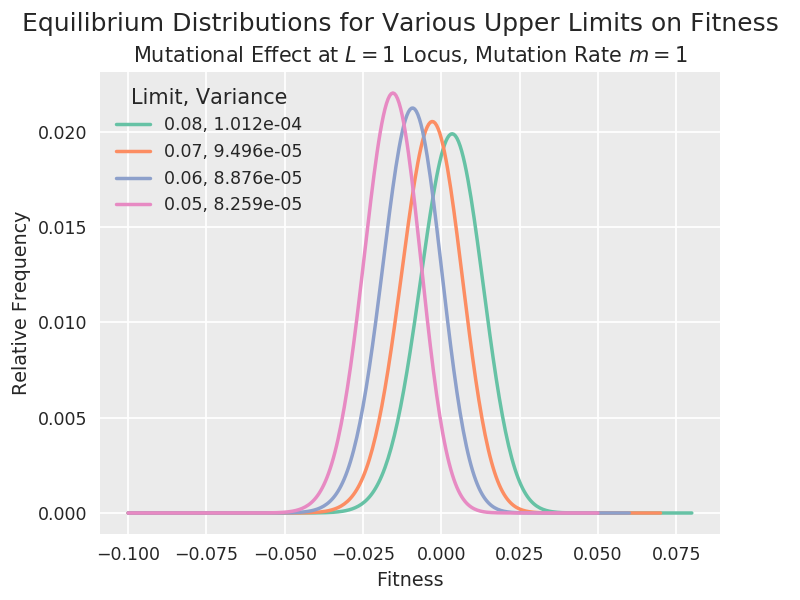

<IPython.core.display.Javascript object>


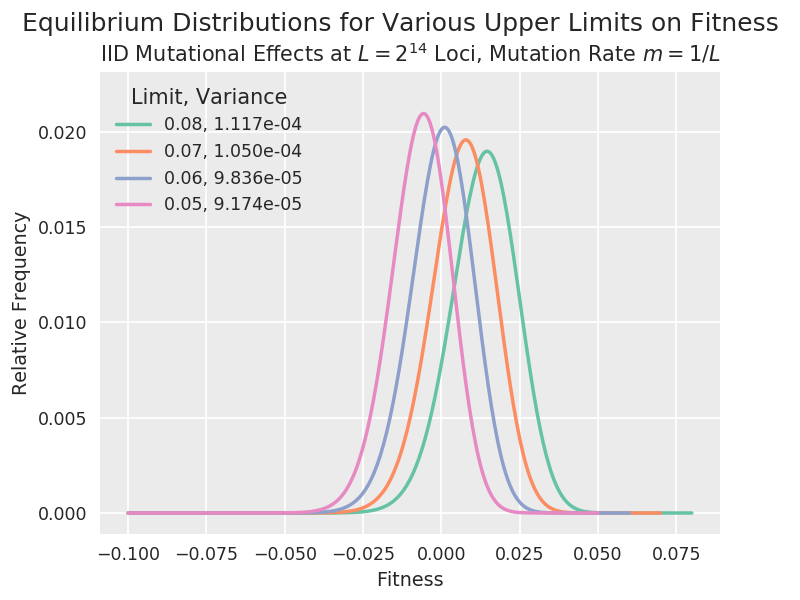

In [5]:
def plot_equilibria(title, equilibria, upper_limits, factors):
    fig, ax = plt.subplots()
    fig.suptitle('Equilibrium Distributions for Various Upper Limits on Fitness')
    ax.set_title(title)
    ax.set_ylabel('Relative Frequency')
    ax.set_xlabel('Fitness')
    for eq, limit, f in zip(equilibria, upper_limits, factors):
        _, variance = mean_and_variance(f.growth, eq)
        ax.plot(f.growth, eq, label='{0}, {1:5.3e}'.format(limit, variance))
    ax.legend(title='Limit, Variance', loc='upper left')
    return fig, ax

fig, ax = plot_equilibria('Mutational Effect at $L=1$ Locus, Mutation Rate $m=1$', eq_one_locus, upper_limits, factors)
ylim = ax.get_ylim()
fig, ax = plot_equilibria('IID Mutational Effects at $L=2^{14}$ Loci, Mutation Rate $m=1/L$', eq_many_loci, upper_limits, factors)
ax.set_ylim(ylim);

Note that the right tail of each equilibrium distribution is plotted only to the upper limit. All left tails extend to -0.1.